# Week 2 Assignment — ML Pipeline on Tesla Deliveries Data
**Name:** Sunami Agarwal  
**Dataset:** Tesla EA Deliveries and Production Data (2015–2025)  
**Goal:** Build an end-to-end ML pipeline — preprocessing → EDA → feature engineering → regression → hyperparameter tuning → time series forecasting


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
import joblib

print("all imports OK")


all imports OK


## 1. Loading the Dataset

In [87]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [88]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print()
df.info()


Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging

In [89]:
df.describe()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [90]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [91]:
df.describe().round(2)


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


## 2. Data Cleaning


In [93]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total missing: 0


In [94]:
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {n_before - len(df)} duplicate rows. Shape now: {df.shape}")


Removed 0 duplicate rows. Shape now: (2640, 12)


In [95]:
for col in ['Avg_Price_USD', 'Range_km', 'Production_Units']:
    if col in df.columns and df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  filled {col} nulls with median = {median_val:,.0f}")

rows_before = len(df)
df.dropna(subset=['Estimated_Deliveries'], inplace=True)
print(f"\nDropped {rows_before - len(df)} rows with missing target")

note_cols = [c for c in df.columns
             if df[c].dtype == 'object' and c not in ['Region', 'Model']]
if note_cols:
    print(f"Dropping non-useful text columns: {note_cols}")
    df.drop(columns=note_cols, inplace=True)

print(f"\nMissing values remaining:\n{df.isnull().sum()}")



Dropped 0 rows with missing target
Dropping non-useful text columns: ['Source_Type']

Missing values remaining:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Charging_Stations       0
dtype: int64


In [96]:
df.dtypes


Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Charging_Stations         int64
dtype: object

In [97]:
df['date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))
df = df.sort_values('date').reset_index(drop=True)

print("Date range:", df['date'].min().date(), "→", df['date'].max().date())
df[['Year', 'Month', 'date']].head()


Date range: 2015-01-01 → 2025-12-01


,Year,Month,date
0,2015,1,2015-01-01
1,2015,1,2015-01-01
2,2015,1,2015-01-01
3,2015,1,2015-01-01
4,2015,1,2015-01-01


## 3. Exploratory Data Analysis (EDA)


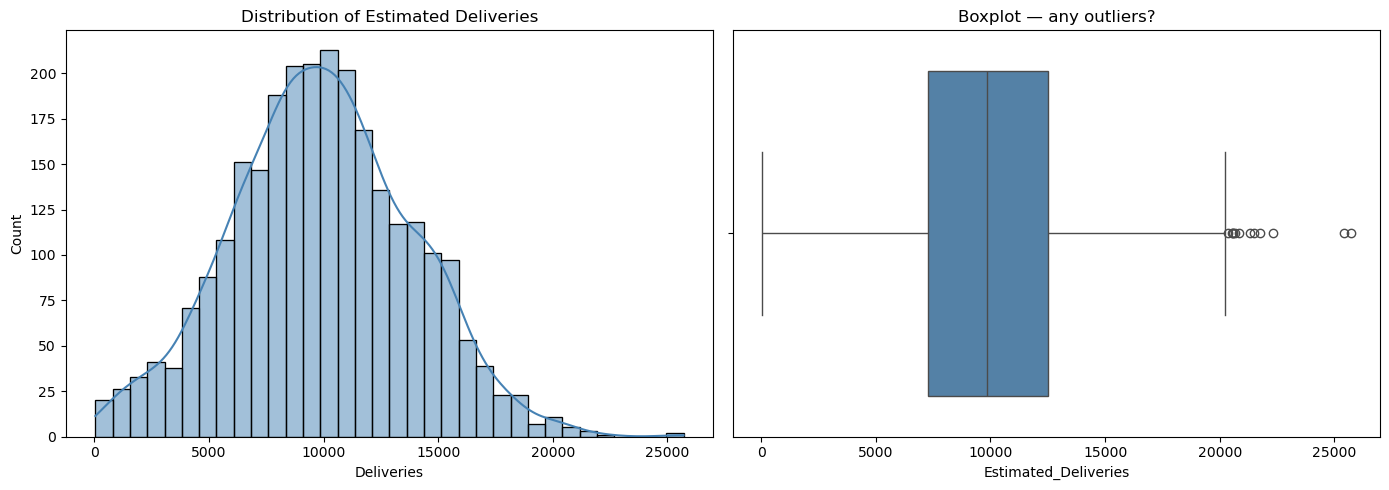

Skewness: 0.088  (roughly symmetric)


In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Estimated_Deliveries'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Estimated Deliveries')
axes[0].set_xlabel('Deliveries')

sns.boxplot(x=df['Estimated_Deliveries'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot — any outliers?')

plt.tight_layout()
plt.show()

skew = df['Estimated_Deliveries'].skew()
print(f"Skewness: {skew:.3f}  ({'right-skewed' if skew > 0.5 else 'left-skewed' if skew < -0.5 else 'roughly symmetric'})")


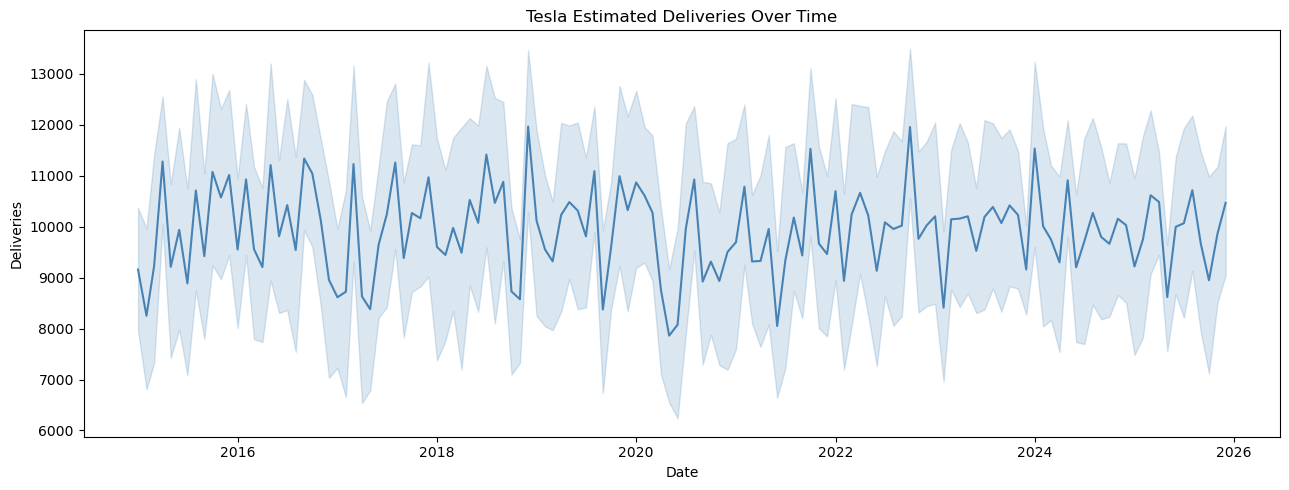

In [100]:
plt.figure(figsize=(13, 5))
sns.lineplot(x='date', y='Estimated_Deliveries', data=df, color='steelblue')
plt.title('Tesla Estimated Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()


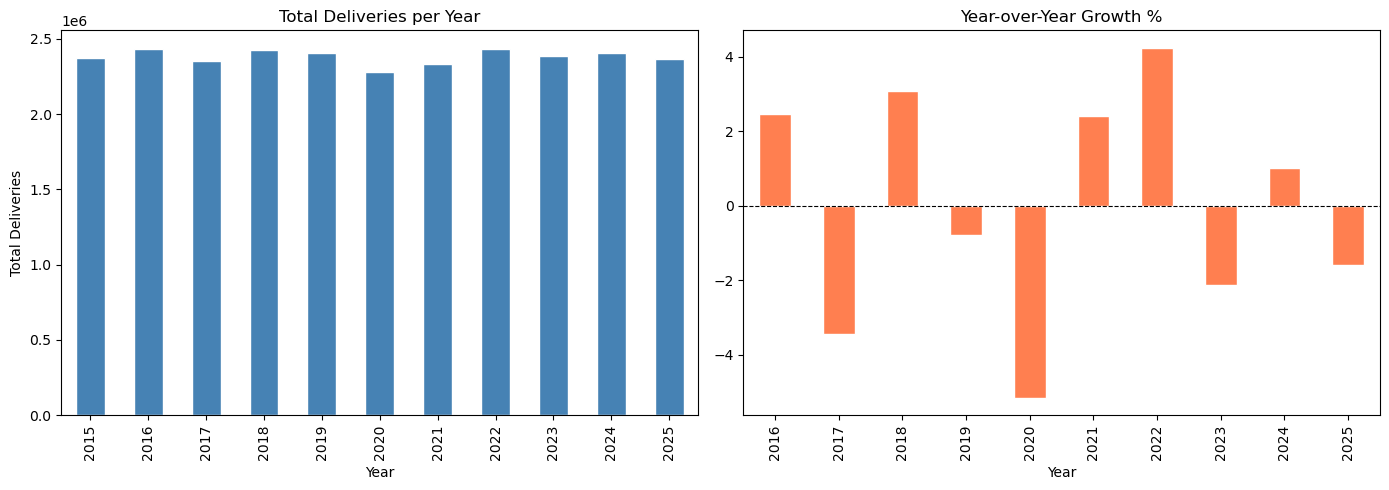

Peak growth year: 2022 (4.2%)


In [101]:
yoy        = df.groupby('Year')['Estimated_Deliveries'].sum()
yoy_growth = yoy.pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yoy.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Total Deliveries per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Deliveries')

yoy_growth.dropna().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Year-over-Year Growth %')
axes[1].set_xlabel('Year')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

print("Peak growth year:", yoy_growth.idxmax(), f"({yoy_growth.max():.1f}%)")


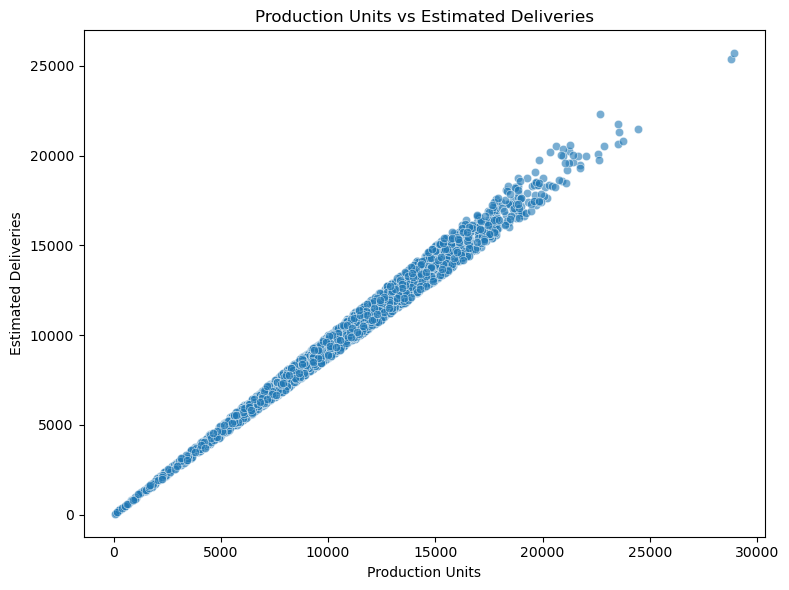

Pearson correlation (Production vs Deliveries): 0.994


In [102]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Production_Units', y='Estimated_Deliveries', data=df, alpha=0.6)
plt.title('Production Units vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

corr = df['Production_Units'].corr(df['Estimated_Deliveries'])
print(f"Pearson correlation (Production vs Deliveries): {corr:.3f}")


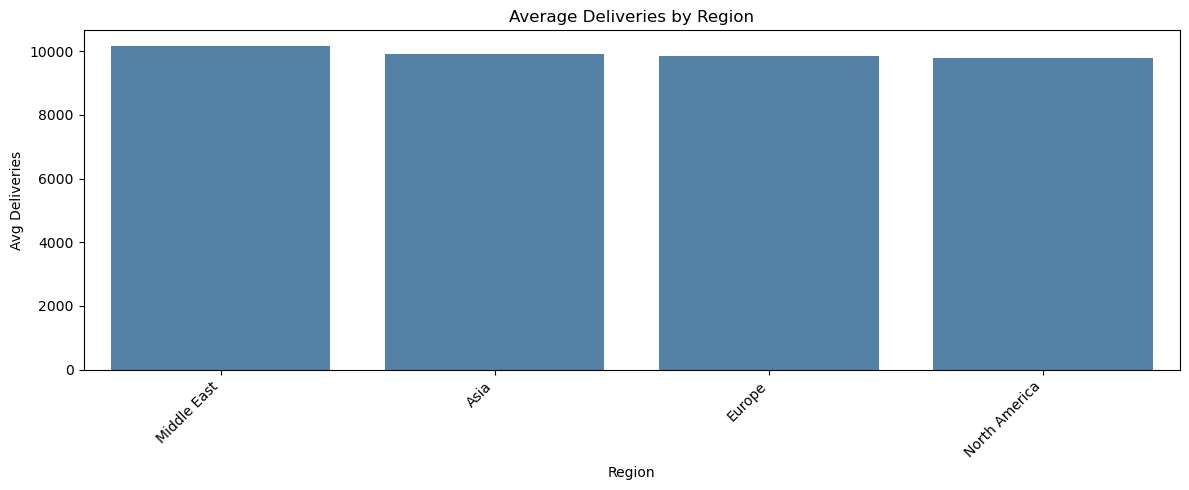

In [103]:
region_avg = (df.groupby('Region')['Estimated_Deliveries']
              .mean()
              .sort_values(ascending=False))

plt.figure(figsize=(12, 5))
sns.barplot(x=region_avg.index, y=region_avg.values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Average Deliveries by Region')
plt.ylabel('Avg Deliveries')
plt.tight_layout()
plt.show()


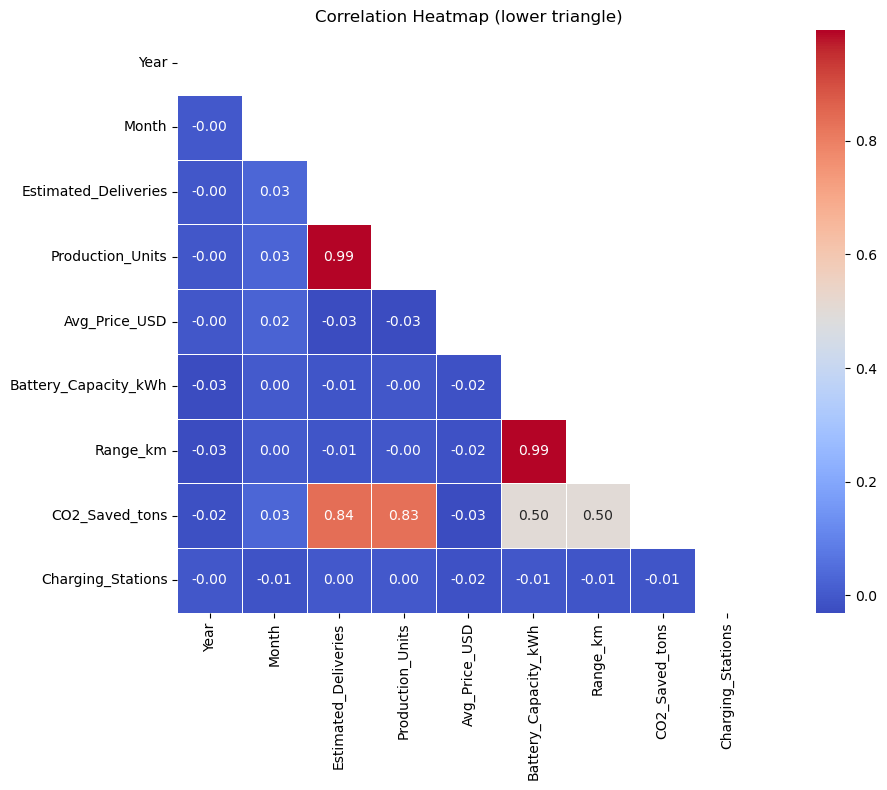

In [104]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # only show lower triangle

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Correlation Heatmap (lower triangle)')
plt.tight_layout()
plt.show()


## 4. Feature Engineering


In [106]:
df['delivery_ratio'] = df['Estimated_Deliveries'] / df['Production_Units'].replace(0, np.nan)

df['price_per_km'] = df['Avg_Price_USD'] / df['Range_km'].replace(0, np.nan)

df['quarter'] = ((df['Month'] - 1) // 3) + 1

df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df['lag_1'] = df['Estimated_Deliveries'].shift(1)

df['rolling_mean_3'] = df['Estimated_Deliveries'].shift(1).rolling(window=3).mean()

n_before = len(df)
df.dropna(inplace=True)
print(f"Dropped {n_before - len(df)} rows due to lag/rolling NaNs")
print(f"Final shape: {df.shape}")
df[['lag_1', 'rolling_mean_3', 'month_sin', 'month_cos', 'quarter']].head()


Dropped 3 rows due to lag/rolling NaNs
Final shape: (2637, 19)


,lag_1,rolling_mean_3,month_sin,month_cos,quarter
3,8803.0,10898.333333,0.5,0.866025,1
4,6367.0,8872.000000,0.5,0.866025,1
5,8795.0,7988.333333,0.5,0.866025,1
6,2161.0,5774.333333,0.5,0.866025,1
7,11986.0,7647.333333,0.5,0.866025,1


## 5. Train / Test Split

In [108]:
X = df.drop(columns=['Estimated_Deliveries', 'date'])
y = df['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"Target range : {y.min():,.0f} — {y.max():,.0f}")


Training set : (2109, 17)
Test set     : (528, 17)
Target range : 48 — 25,704


## 6. Building sklearn Pipelines


In [110]:
numerical_cols   = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns   ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


Numerical columns   (15): ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'delivery_ratio', 'price_per_km', 'quarter', 'month_sin', 'month_cos', 'lag_1', 'rolling_mean_3']
Categorical columns (2): ['Region', 'Model']


In [111]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
], remainder='drop')

# linear regression — simple baseline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# random forest — should handle non-linear relationships better
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("both models trained")


both models trained


## 7. Model Evaluation


In [113]:
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    preds   = pipeline.predict(X_te)
    cv_r2   = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='r2').mean()
    return {
        'Model'        : name,
        'R² test'      : round(r2_score(y_te, preds), 4),
        'R² 5-fold CV' : round(cv_r2, 4),
        'MAE'          : round(mean_absolute_error(y_te, preds), 0),
        'RMSE'         : round(np.sqrt(mean_squared_error(y_te, preds)), 0),
    }

results = []
results.append(evaluate_model('Linear Regression', lr_pipeline, X_train, y_train, X_test, y_test))
results.append(evaluate_model('Random Forest',     rf_pipeline,  X_train, y_train, X_test, y_test))

pd.DataFrame(results)


,Model,R² test,R² 5-fold CV,MAE,RMSE
0,Linear Regression,0.9985,0.9984,105.0,148.0
1,Random Forest,0.9993,0.9979,62.0,98.0


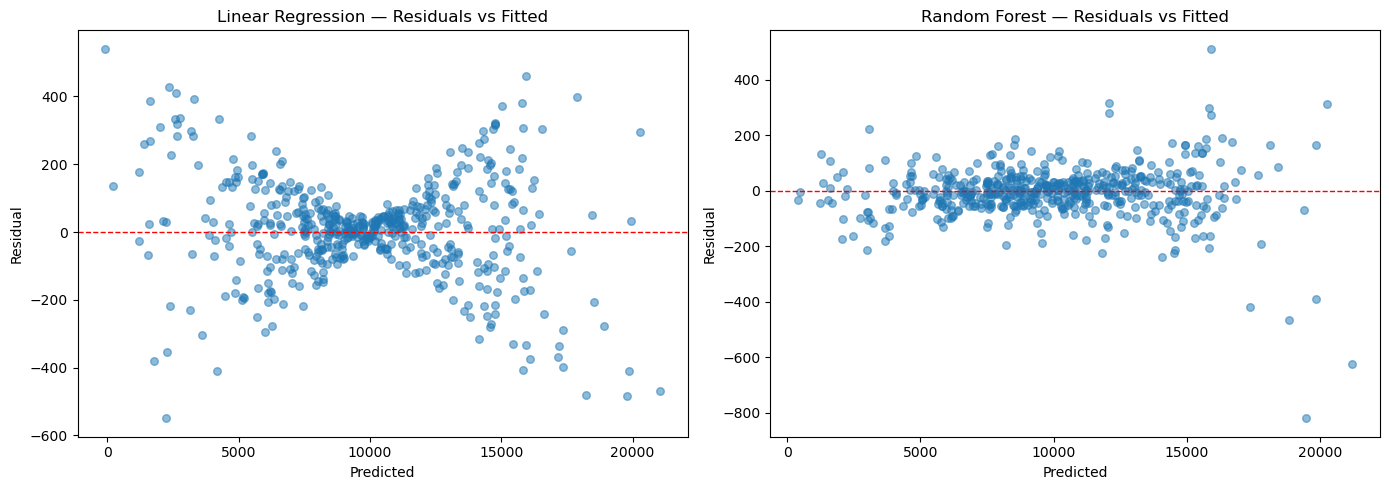

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, pipe in zip(axes,
                           ['Linear Regression', 'Random Forest'],
                           [lr_pipeline, rf_pipeline]):
    preds     = pipe.predict(X_test)
    residuals = y_test - preds

    ax.scatter(preds, residuals, alpha=0.5, s=30)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{name} — Residuals vs Fitted')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')

plt.tight_layout()
plt.show()


## 8. Hyperparameter Tuning

In [116]:
param_grid = {
    'model__n_estimators'    : [100, 200],
    'model__max_depth'       : [5, 10, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf' : [1, 2],
    'model__max_features'    : ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Year',
                                                                          'Month',
                                                                          'Production_Units',
                                                                          'Avg_Price_USD',
                                                                          'Battery_Capacity_kWh',
                                                                          'Range_km',
                                                                          'CO2_Saved_tons',
                                                                          'Charging_Stations',
                                                                          'delivery_ratio',
                                                                          'price_per_km',
                                                                          'quarter',
                                                                          'month_sin',
                                                                          'month_cos',
                                                                          'lag_1',
                                                                          'rolling_mean_3']),
                                                                        ('cat',
                                                                         OneHotEncode..._unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['Region',
                                                                          'Model'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [117]:
print("Best parameters found:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: {-grid_search.best_score_:,.0f}")


Best parameters found:
  model__max_depth: None
  model__max_features: sqrt
  model__min_samples_leaf: 1
  model__min_samples_split: 2
  model__n_estimators: 200

Best CV RMSE: 748


In [118]:
best_model = grid_search.best_estimator_

results.append(evaluate_model('RF Tuned', best_model, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results)
print("=== Final Model Comparison ===")
display(results_df)


=== Final Model Comparison ===


,Model,R² test,R² 5-fold CV,MAE,RMSE
0,Linear Regression,0.9985,0.9984,105.0,148.0
1,Random Forest,0.9993,0.9979,62.0,98.0
2,RF Tuned,0.9759,0.9641,375.0,593.0


## 9. Feature Importance

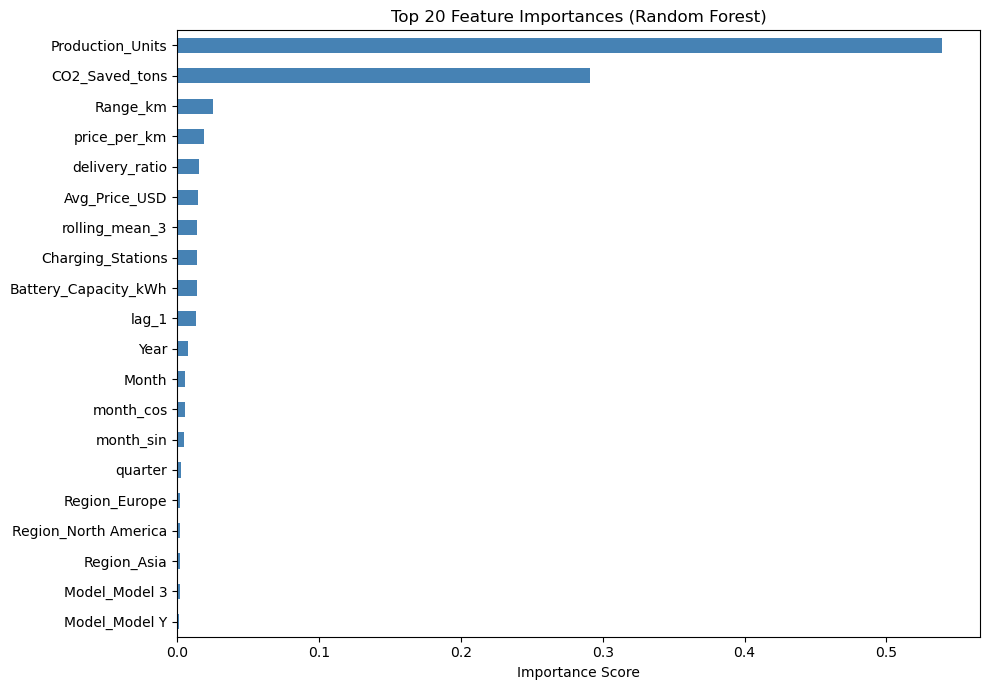

Top 5 features:
Production_Units    0.539011
CO2_Saved_tons      0.291103
Range_km            0.025375
price_per_km        0.018598
delivery_ratio      0.015271


In [120]:
ohe_names = (best_model
             .named_steps['preprocessor']
             .named_transformers_['cat']
             .get_feature_names_out(categorical_cols)
             .tolist())

all_features = numerical_cols + ohe_names

importance = pd.Series(
    best_model.named_steps['model'].feature_importances_,
    index=all_features
).sort_values()

# only plot top 20 so it doesn't get too crowded
importance.tail(20).plot(kind='barh', figsize=(10, 7), color='steelblue')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importance.tail(5).sort_values(ascending=False).to_string())


## 10. Time Series Forecasting with SARIMA


Time series length: 132 months
Range: 2015-01-01 → 2025-12-01


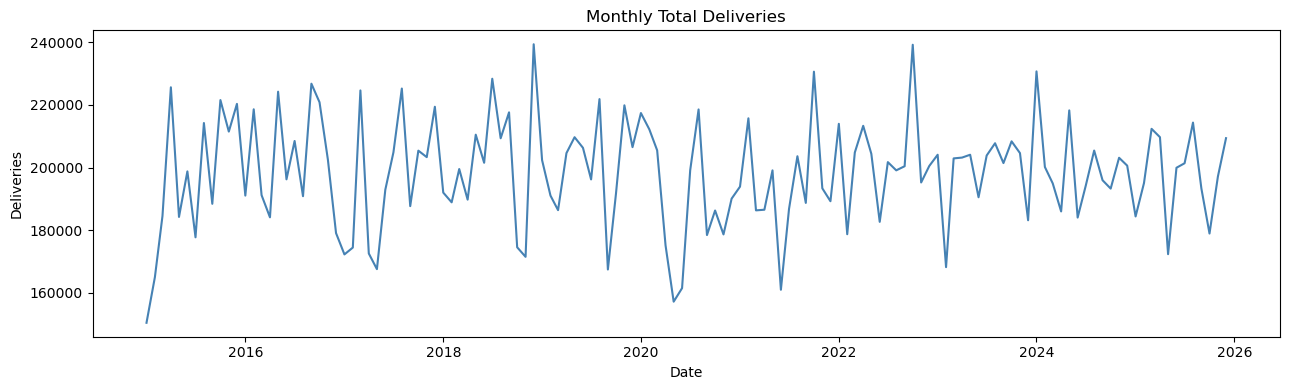

In [122]:
# aggregate to monthly totals — need a single series indexed by date
ts = df.groupby('date')['Estimated_Deliveries'].sum().sort_index()

print(f"Time series length: {len(ts)} months")
print(f"Range: {ts.index[0].date()} → {ts.index[-1].date()}")

plt.figure(figsize=(13, 4))
plt.plot(ts.index, ts.values, color='steelblue')
plt.title('Monthly Total Deliveries')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()


In [123]:
adf_stat, p_val, _, _, crit_vals, _ = adfuller(ts.dropna())

print(f"ADF Statistic : {adf_stat:.4f}")
print(f"p-value       : {p_val:.4f}")
print(f"Critical values: {crit_vals}")
print(f"\nResult: {'stationary ✓' if p_val < 0.05 else 'non-stationary — auto_arima will difference it'}")


ADF Statistic : -8.9602
p-value       : 0.0000
Critical values: {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}

Result: stationary ✓


In [124]:
HOLDOUT = 6   # hold out last 6 months as unseen test data

ts_train = ts.iloc[:-HOLDOUT]
ts_test  = ts.iloc[-HOLDOUT:]

print(f"Training: {ts_train.index[0].date()} → {ts_train.index[-1].date()}  ({len(ts_train)} months)")
print(f"Holdout : {ts_test.index[0].date()}  → {ts_test.index[-1].date()}  ({len(ts_test)} months)")


Training: 2015-01-01 → 2025-06-01  (126 months)
Holdout : 2025-07-01  → 2025-12-01  (6 months)


In [125]:
sarima_model = pm.auto_arima(
    ts_train,
    seasonal=True,
    m=3,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True
)

print(sarima_model.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  126
Model:                        SARIMAX   Log Likelihood               -1409.748
Date:                Sun, 31 May 2026   AIC                           2823.496
Time:                        20:49:01   BIC                           2829.169
Sample:                    01-01-2015   HQIC                          2825.801
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1.982e+05   1567.428    126.419      0.000    1.95e+05    2.01e+05
sigma2       3.06e+08   4.02e+07      7.610      0.000    2.27e+08    3.85e+08
Ljung-Box (L1) (Q):                   0.22   Jarque-

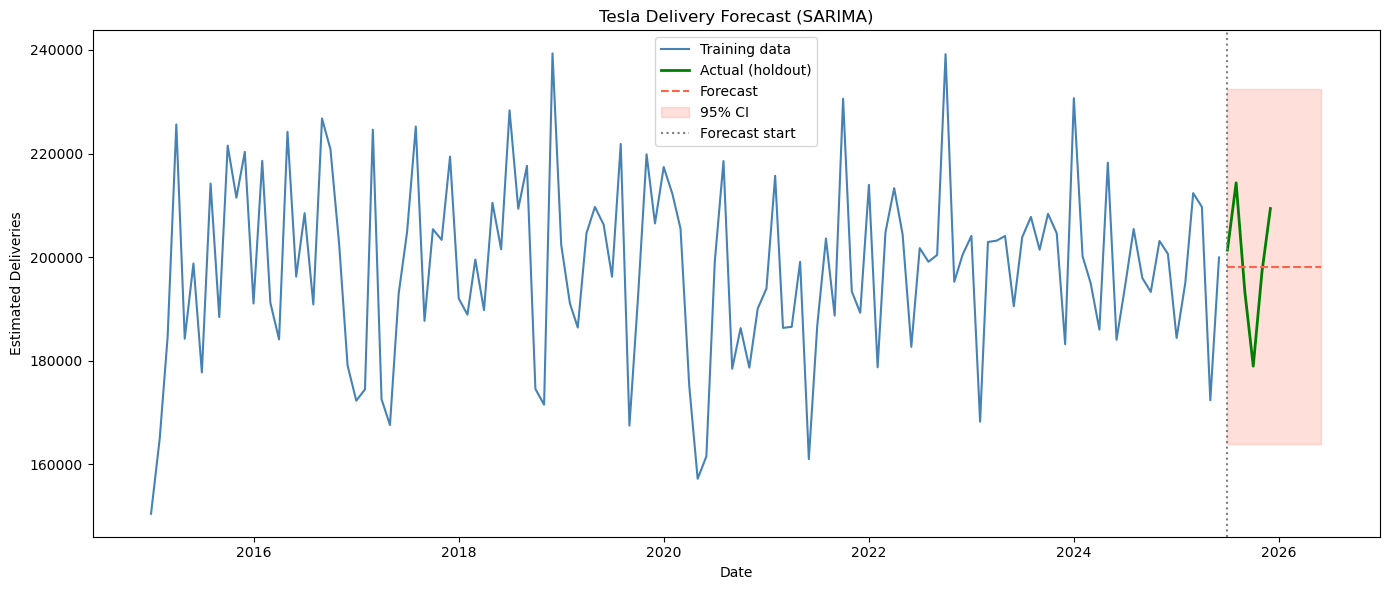

In [126]:
n_forecast   = HOLDOUT + 6   # 6 holdout + 6 future months
forecast_vals, conf_int = sarima_model.predict(n_periods=n_forecast, return_conf_int=True)
forecast_idx = pd.date_range(start=ts_test.index[0], periods=n_forecast, freq='MS')

plt.figure(figsize=(14, 6))
plt.plot(ts_train.index, ts_train,       color='steelblue', label='Training data')
plt.plot(ts_test.index,  ts_test,        color='green',     label='Actual (holdout)', linewidth=2)
plt.plot(forecast_idx,   forecast_vals,  color='tomato',    label='Forecast', linestyle='--')
plt.fill_between(forecast_idx,
                 conf_int[:, 0], conf_int[:, 1],
                 color='tomato', alpha=0.2, label='95% CI')
plt.axvline(x=ts_test.index[0], color='gray', linestyle=':', linewidth=1.5, label='Forecast start')

plt.title('Tesla Delivery Forecast (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()


In [127]:
holdout_pred = forecast_vals[:HOLDOUT]

mae_ts  = mean_absolute_error(ts_test, holdout_pred)
rmse_ts = np.sqrt(mean_squared_error(ts_test, holdout_pred))
mape    = np.mean(np.abs((ts_test.values - holdout_pred) / ts_test.values)) * 100

print(f"SARIMA holdout accuracy ({HOLDOUT} months):")
print(f"  MAE  : {mae_ts:>10,.0f}")
print(f"  RMSE : {rmse_ts:>10,.0f}")
print(f"  MAPE : {mape:>9.1f}%")


SARIMA holdout accuracy (6 months):
  MAE  :      9,282
  RMSE :     11,487
  MAPE :       4.7%


## 11. Saving the Model

In [129]:
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/tesla_rf_pipeline.pkl')
print("Model saved → models/tesla_rf_pipeline.pkl")

# quick sanity check: reload and predict on one test row
loaded_model = joblib.load('models/tesla_rf_pipeline.pkl')
sample_pred  = loaded_model.predict(X_test.iloc[[0]])
print(f"Sanity check — prediction on first test row: {sample_pred[0]:,.0f}")
print(f"Actual value: {y_test.iloc[0]:,.0f}")


Model saved → models/tesla_rf_pipeline.pkl
Sanity check — prediction on first test row: 13,143
Actual value: 13,280
